In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
n = 50
m = 10**4

thetas = 0  # prawdziwa wartość oczekiwana (dla N(0,1))
ks = np.arange(10, 101, 10)

In [3]:
def est_1(x):
    return np.mean(x)

In [4]:
def est_2(x):
    return np.median(x)

In [5]:
estimators = [est_1, est_2]

In [6]:
def generate_sample(size, k):
    return np.append(np.random.randn(size - 1), [k])

In [7]:
def theta_stats(estimates, true_theta):
    estimates = np.array(estimates)  
    mean_est = np.mean(estimates)
    var_est = np.var(estimates, ddof=1) # żeby dzieliło przez n-ddof
    bias = mean_est - true_theta
    mse = np.mean((estimates - true_theta)**2)
    return {"mean": mean_est, "var": var_est, "bias": bias, "mse": mse}

In [8]:
stats_for_k = {}
for k in ks:
    estimates = {f"est_{i+1}": [] for i in range(len(estimators))}
    for _ in range(m):
        data = generate_sample(n, k)
        for i, est in enumerate(estimators):
            estimates[f"est_{i+1}"].append(est(data))
    stats_for_k[k] = {name: theta_stats(values, thetas)
                      for name, values in estimates.items()}
    

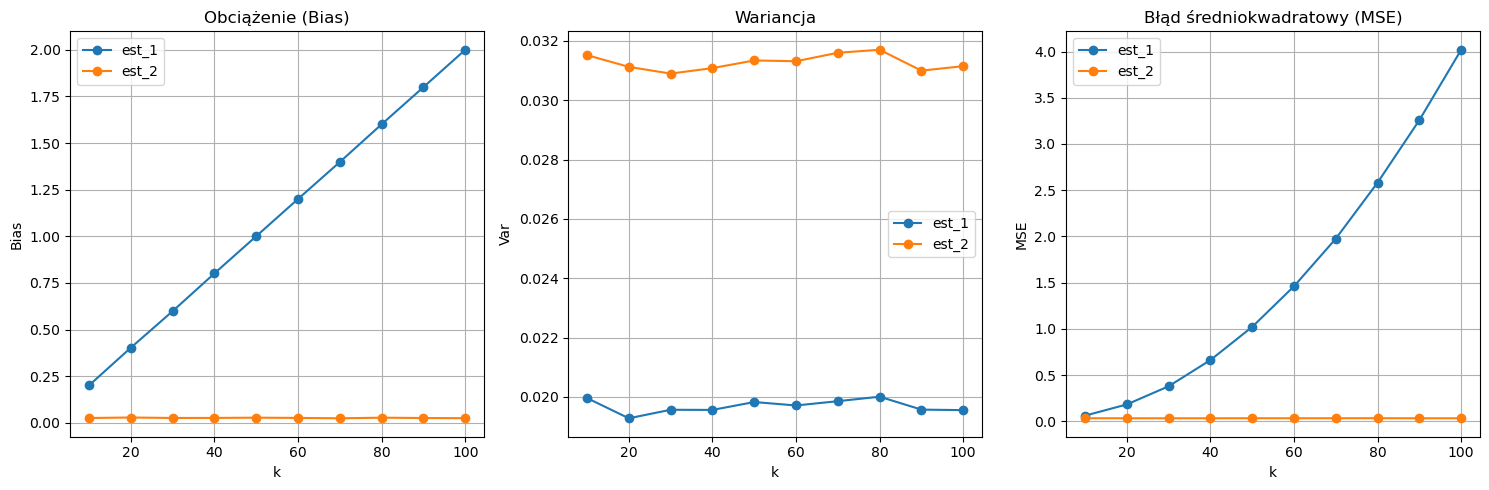

In [11]:
import os
import pandas as pds

os.makedirs("plots", exist_ok=True)

# Konwersja wyników do wykresów
means = {name: [stats_for_k[k][name]["mean"] for k in ks] for name in estimates} # tego nie trzeba było porównywać
biases = {name: [stats_for_k[k][name]["bias"] for k in ks] for name in estimates}
variances = {name: [stats_for_k[k][name]["var"] for k in ks] for name in estimates}
mses = {name: [stats_for_k[k][name]["mse"] for k in ks] for name in estimates}

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1) 
for name, vals in biases.items():
    plt.plot(ks, vals, marker='o', label=name)
plt.title("Obciążenie (Bias)")
plt.xlabel("k")
plt.ylabel("Bias")
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
for name, vals in variances.items():
    plt.plot(ks, vals, marker='o', label=name)
plt.title("Wariancja")
plt.xlabel("k")
plt.ylabel("Var")
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
for name, vals in mses.items():
    plt.plot(ks, vals, marker='o', label=name)
plt.title("Błąd średniokwadratowy (MSE)")
plt.xlabel("k")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)

plt.tight_layout()

png_filename = f"plots/plot.png"
plt.savefig(png_filename)

plt.show()
plt.close()